## run these 2 cells first

In [15]:
import sys, subprocess
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy', 'scikit-learn', 'nbformat'],
    check=True,)


CompletedProcess(args=['/Users/sahanadhar/anaconda3/envs/sahana/bin/python', '-m', 'pip', 'install', '-q', 'numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy', 'scikit-learn', 'nbformat'], returncode=0)

In [16]:
%run 02_hmm.ipynb


# Notebook 4: Experiments + Comparison
1. Load the clinical CSV and pick features
2. Build the train/test split
3. HMM on clinical features (the only model we have right now)
4. Smoothed CDR transition matrix
5. Macro F1 comparison vs the majority and Naive Bayes baselines
6. Discussion

#### 1. Load the Clinical CSV and Pick Features
- load `clinical.csv`, drop CDR=2 (only 3 rows)
- score every clinical column by Pearson correlation with CDR, keep top 5
- exclude visit number and MR delay (time stamps, not clinical signal)

top-5 features chosen: ['MMSE', 'nWBV', 'Sex_male', 'EDUC', 'SES']


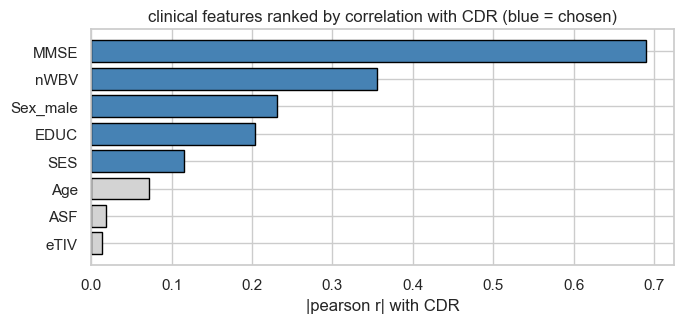

In [17]:
clinical_df = pd.read_csv("../data/clinical.csv")
clinical_df = clinical_df.loc[clinical_df["CDR"] != 2].copy().reset_index(drop=True)
clinical_df["Sex_male"] = (clinical_df["M/F"] == "M").astype(float)

candidate_cols = [c for c in ["Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF", "Sex_male"] if c in clinical_df.columns]
correlation_with_cdr = clinical_df[candidate_cols + ["CDR"]].corr(numeric_only=True)["CDR"].drop("CDR")
correlation_by_strength = correlation_with_cdr.reindex(correlation_with_cdr.abs().sort_values(ascending=False).index)

top5_features = list(correlation_by_strength.index[:5])
print("top-5 features chosen:", top5_features)

fig, ax = plt.subplots(figsize=(7, 3.4))
bar_colors = ["steelblue" if c in top5_features else "lightgray" for c in correlation_by_strength.index]
ax.barh(correlation_by_strength.index, correlation_by_strength.abs().values, color=bar_colors, edgecolor="black")
ax.set_xlabel("|pearson r| with CDR")
ax.set_title("clinical features ranked by correlation with CDR (blue = chosen)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 2. Train / Test Strategy

- 75% train, 25% test, `random_state=42` (reproducible), split by patient, not by visit
- stratified on baseline CDR (each patient's first-visit CDR) so the rare CDR=1 patients show up in both folds
- scaler is fit on training patients only 

In [18]:
sequence_df = clinical_df[top5_features + ["Subject ID", "Visit", "CDR"]].dropna().sort_values(["Subject ID", "Visit"])
# only keep patients with at least 2 visits
patients_with_chains = np.array([sid for sid, group in sequence_df.groupby("Subject ID") if len(group) >= 2])
# each patient's first-visit cdr (used for the stratified split)
baseline_cdr_class = (sequence_df.groupby("Subject ID")["CDR"].first().reindex(patients_with_chains)
    .map(lambda x: int(round(float(x),  2))).values)

train_patients, test_patients = train_test_split(patients_with_chains, test_size=0.25, random_state=42, stratify=baseline_cdr_class)
train_patient_ids = set(train_patients)
test_patient_ids  = set(test_patients)

print(f"patients with >=2 visits:{len(patients_with_chains)}")
print(f"train/ test patients: {len(train_patient_ids)} / {len(test_patient_ids)}")


patients with >=2 visits:139
train/ test patients: 104 / 35


## 3. HMM on Clinical Features
1. standardizes using training patients only
2. PCA-whitens (rotates features to be uncorrelated, then rescales each axis to variance 1)
3. fits our from-scratch HMM with  random restarts and keeps the best
4. uses the Hungarian algorithm to map hidden states to CDR levels
5. decodes the test set with Viterbi
6. compares against the majority and Naive Bayes baselines
7. prints the classification report and shows the confusion matrix

clinical features
features: 5 columns | train/test visits: 254 / 94
best training log-likelihood: -1531.29
state -> cdr (hungarian): {0: 0.0, 1: 0.5, 2: 1.0}  (train agreement 58.7%)

              precision    recall  f1-score   support

       CDR 0      0.787     0.561     0.655        66
     CDR 0.5      0.118     0.105     0.111        19
       CDR 1      0.267     0.889     0.410         9

    accuracy                          0.500        94
   macro avg      0.391     0.518     0.392        94
weighted avg      0.602     0.500     0.522        94

  majority class          macro f1 = 0.275   balanced acc = 0.333
  gaussian naive bayes    macro f1 = 0.698   balanced acc = 0.654
  hmm + viterbi           macro f1 = 0.392   balanced acc = 0.518


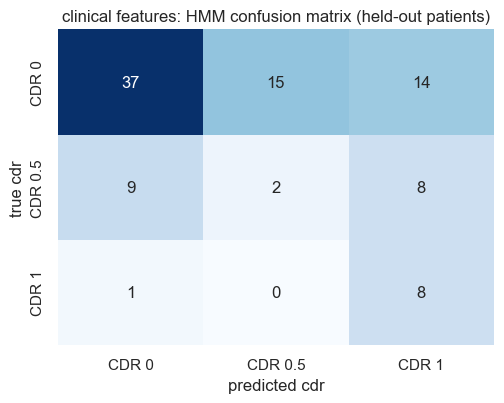

In [19]:
results_clinical = run_hmm_pipeline("clinical features", sequence_df, top5_features, train_patient_ids, test_patient_ids)


## 4. CDR Transition Matrix (smoothed)

- the HMM's transition matrix says "given current hidden state, what's the chance of moving to each next state"
- problem: the version Baum-Welch fits is ~ the identity matrix because chains are short
- estimate it directly from the training CDR sequences and add a Dirichlet prior 
- our fake counts(prior) is asymmetric: bigger fake counts on the diagonal and bigger fake counts forward than backward (dementia rarely improves)

Note: this smoothed matrix is for interpretation only. The Viterbi decoding above uses the Baum-Welch transition matrix, so the test metrics aren't helped by the prior.

observed training transitions:
          to 0  to 0.5  to 1
from 0      78      10     0
from 0.5     2      43     6
from 1       0       1    10


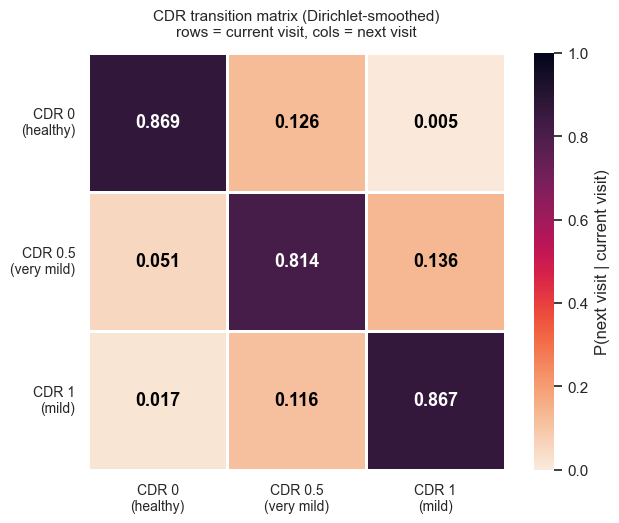

progression: 0 -> 0.5 = 0.126    0.5 -> 1 = 0.136
regression:  0.5 -> 0 = 0.051    1 -> 0.5 = 0.116
stickiness:  0 -> 0   = 0.869    0.5 -> 0.5 = 0.814    1 -> 1 = 0.867


In [20]:
dirichlet_prior = np.array([
    [5.0, 2.0, 0.5],   # from CDR 0
    [1.0, 5.0, 2.0],   # from CDR 0.5
    [0.3, 1.0, 5.0],   # from CDR 1
])

observed_transition_counts = count_observed_cdr_transitions(sequence_df, train_patient_ids)
smoothed_transitions = smooth_transition_matrix(observed_transition_counts, dirichlet_prior)

print("observed training transitions:")
print(pd.DataFrame(observed_transition_counts.astype(int),
                   index=["from 0", "from 0.5", "from 1"],
                   columns=["to 0", "to 0.5", "to 1"]))

cdr_labels = ["CDR 0\n(healthy)", "CDR 0.5\n(very mild)", "CDR 1\n(mild)"]
fig, ax = plt.subplots(figsize=(6.8, 5.4))
sns.heatmap(smoothed_transitions, annot=True, fmt=".3f", cmap="rocket_r", vmin=0, vmax=1,
            xticklabels=cdr_labels, yticklabels=cdr_labels, square=True,
            linewidths=1.0, linecolor="white",
            cbar_kws={"label": "P(next visit | current visit)"},
            annot_kws={"fontsize": 13, "fontweight": "bold"}, ax=ax)
for txt, val in zip(ax.texts, smoothed_transitions.ravel()):
    txt.set_color("white" if val > 0.55 else "black")
ax.set_title("CDR transition matrix (Dirichlet-smoothed)\nrows = current visit, cols = next visit", fontsize=11, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

print(f"progression: 0 -> 0.5 = {smoothed_transitions[0, 1]:.3f}    0.5 -> 1 = {smoothed_transitions[1, 2]:.3f}")
print(f"regression:  0.5 -> 0 = {smoothed_transitions[1, 0]:.3f}    1 -> 0.5 = {smoothed_transitions[2, 1]:.3f}")
print(f"stickiness:  0 -> 0   = {smoothed_transitions[0, 0]:.3f}    0.5 -> 0.5 = {smoothed_transitions[1, 1]:.3f}    1 -> 1 = {smoothed_transitions[2, 2]:.3f}")


## 5. Macro F1 Comparison

HMM vs. the two baselines (same test set, same features). Higher is better.

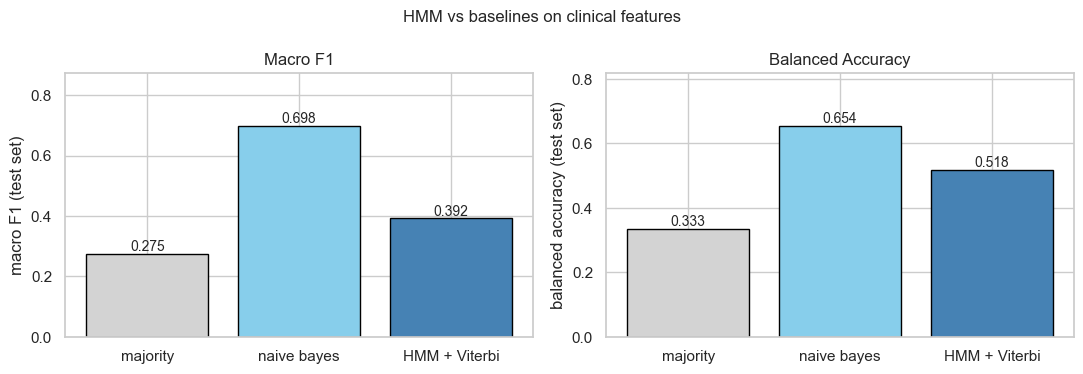


summary:
  features          : 5
  test visits       : 94
  HMM macro F1      : 0.392    HMM balanced acc      : 0.518
  NB macro F1       : 0.698    NB balanced acc       : 0.654
  majority macro F1 : 0.275    majority balanced acc : 0.333


In [21]:
r = results_clinical
labels = ["majority", "naive bayes", "HMM + Viterbi"]
colors = ["lightgray", "skyblue", "steelblue"]

f1_scores  = [r["majority_macro_f1"],         r["gnb_macro_f1"],         r["hmm_macro_f1"]]
acc_scores = [r["majority_balanced_accuracy"], r["gnb_balanced_accuracy"], r["hmm_balanced_accuracy"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# left: macro F1
bars = axes[0].bar(labels, f1_scores, color=colors, edgecolor="black")
for bar, score in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, score + 0.01, f"{score:.3f}", ha="center", fontsize=10)
axes[0].set_ylabel("macro F1 (test set)")
axes[0].set_title("Macro F1")
axes[0].set_ylim(0, max(f1_scores) * 1.25)

# right: balanced accuracy
bars = axes[1].bar(labels, acc_scores, color=colors, edgecolor="black")
for bar, score in zip(bars, acc_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, score + 0.01, f"{score:.3f}", ha="center", fontsize=10)
axes[1].set_ylabel("balanced accuracy (test set)")
axes[1].set_title("Balanced Accuracy")
axes[1].set_ylim(0, max(acc_scores) * 1.25)

fig.suptitle("HMM vs baselines on clinical features", fontsize=12)
plt.tight_layout()
plt.show()

print("\nsummary:")
print(f"  features          : {r['n_features']}")
print(f"  test visits       : {r['n_visits_test']}")
print(f"  HMM macro F1      : {r['hmm_macro_f1']:.3f}    HMM balanced acc      : {r['hmm_balanced_accuracy']:.3f}")
print(f"  NB macro F1       : {r['gnb_macro_f1']:.3f}    NB balanced acc       : {r['gnb_balanced_accuracy']:.3f}")
print(f"  majority macro F1 : {r['majority_macro_f1']:.3f}    majority balanced acc : {r['majority_balanced_accuracy']:.3f}")


#### Discussion

What worked
- our from-scratch HMM separates the three CDR levels in PCA-whitened space
- Hungarian alignment finds an unambiguous mapping: 
state 0 -> CDR 0, state 1 -> CDR 0.5, state 2 -> CDR 1
- the smoothed transition matrix is interpretable
- almost no two-step errors in the confusion matrix, so the model has learned the ordering of CDR even though we never told it CDR is ordinal

What didn't
- the HMM does not beat the Gaussian Naive Bayes baseline on the clinical features
- with only 2 to 5 visits per patient, Baum-Welch can't really learn the transition dynamics, so the temporal piece isn't paying off
- most of the predictive signal lives in the per-visit features, which Naive Bayes already uses without any sequence modeling
- the model over-predicts CDR 0.5 when the truth is CDR 0 (high recall, low precision on the middle class)

notes:
  Plain accuracy = "out of all 85 test visits, how many did the model get exactly right?"
  Recall for one class = "of all the visits that are actually this class, how many did the model catch?
  - recall for CDR 0 = "of the 46 true CDR-0 visits, how many did the model correctly call CDR 0?"
  - recall for CDR 0.5 = "of the 29 true CDR-0.5 visits, how many did the model correctly call CDR 0.5?"
  - recall for CDR 1 = "of the 10 true CDR-1 visits, how many did the model correctly call CDR 1?"      
  Balanced accuracy = average of those three numbers.
  F1 is a single number that combines two things for one class:
  - precision: when the model says "this visit is CDR X", how often is it actually right?
  - recall: of all the visits that are truly CDR X, how many did the model catch? 